# Final Training

## Imports

In [ ]:
# only uncomment and install what is required
# !pip install imblearn
# !pip install scikit-learn
# !pip install imblearn
# !pip install xgboost

In [1]:
import pandas as pd
import numpy as np
import pandas as pd
import joblib
from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
import xgboost as xgb
from sklearn import tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import StackingClassifier
import traceback
from sklearn.metrics import f1_score
from sklearn.model_selection import StratifiedKFold
import matplotlib.pyplot as plt

# Defining helper functions

In [2]:
# does a stratified train/test split

# To split train/test data, test_size=0.30
def dataset_train_test_split_stratified_for_sub_type(df):
    try:
        df = df.dropna(how="any", axis=0)
        df.reset_index(drop=True, inplace=True)
        df.playlist_genre = pd.to_numeric(df.playlist_genre)

        if "data_type" not in df.columns:
            X_train, X_test, y_train, y_test = train_test_split(df.loc[:, df.columns != 'playlist_genre'],
                                                                df["playlist_genre"], test_size=0.30, random_state=0)
            df.loc[X_test.index, 'data_type'] = 'test'
            df.data_type = df.data_type.fillna('train')
        else:
            X_train = df[df['data_type'] == 'train']["text_clean"]
            y_train = df[df['data_type'] == 'train']["label"]

            X_test = df[df['data_type'] == 'test']["text_clean"]
            y_test = df[df['data_type'] == 'test']["label"]

        category, count = np.unique(y_train, return_counts=True)

        return X_train, y_train, X_test, y_test
    except Exception as e:
        print(e)

# generates a classification report
# labels = joblib.load(filename='misc/LabelDictionary.joblib')
def classification_report_generator(actual, predicted, model_name):
    report = classification_report(actual, predicted, output_dict=True)
    report_df = pd.DataFrame(report).transpose()
    report_df.to_csv(
        f"{model_name}_classification_report.csv")
    return report

cv = StratifiedKFold(shuffle=True, random_state=0)

# Define the custom evaluation function to calculate f1-score
def f1_eval(y_pred, dtrain):
    return f1_score(dtrain, y_pred, average='weighted')

def weighted_f1_eval(y_pred, dtrain):
    y_true = dtrain.get_label()
    return 'weighted_f1_score', f1_score(y_true, y_pred, average='weighted'), True

# define classifier trainer to train the model 
# this classifier will save a sav file, generate a classification report automatically
# also, it will print each trained model's evaluation scores
# avoid interruption when errors occur, since the running time would be extremely long
# since we once used the Stacking Classifier, it has function regarding the Stacking Classifier
def classifier_trainer(model, model_name, X_train, y_train, X_test, y_test):
    try:
        model.fit(X_train, y_train)
        joblib.dump(model, f"{model_name}_sclf.sav")
        y_predicted = model.predict(X_test)
        report = classification_report_generator(y_test, y_predicted, model_name)

        if model_name != "SC":
            #macro_f1[model_name] = float(report['macro avg']['f1-score'])
            print("Model Trained: %s, Report: %s" % (model_name, report))
        else:
            print("Model Trained: %s, Report: %s" % (model_name, report))
            return model
    except Exception as e:
        print("Error: %s, traceback: %s" % (e, traceback.format_exc()))

## Train models with the selected hyperparameters

In [3]:
# import data
df = pd.read_csv("data/spotify_10000_dualgrams.csv", index_col=0)

# drop lyrics column
df.drop(columns="lyrics", inplace=True)

# split train / test set
X_train, y_train, X_test, y_test = dataset_train_test_split_stratified_for_sub_type(df)

In [16]:
# train 5 models with the hyperparameters we selected after grid search and manual tuning
# GBC - below
print("Training XGB")
XGB = XGBClassifier(eval_metric=f1_eval, tree_method='hist', gamma=0.001, n_estimators=150, max_depth=5, max_bin=10, random_state=42, objective='multi:softmax', n_jobs=None, verbosity=2)
classifier_trainer(XGB, "XGB", X_train, y_train, X_test, y_test)
print("Training DT")
DT = tree.DecisionTreeClassifier(random_state=42)
classifier_trainer(DT, "DT", X_train, y_train, X_test, y_test)
print("Training RFC")
RFC = RandomForestClassifier(max_depth=20, min_samples_leaf=1, min_samples_split=5, n_estimators=200, random_state=42, n_jobs=-1, verbose=3)
classifier_trainer(RFC, "RFC", X_train, y_train, X_test, y_test)
print("Training ABC")
ABC = AdaBoostClassifier(n_estimators=600, algorithm="SAMME.R", learning_rate=0.1, random_state=42)
classifier_trainer(ABC, "ABC", X_train, y_train, X_test, y_test)

Training XGB
Model Trained: XGB, Report: {'0': {'precision': 0.7003577817531306, 'recall': 0.7729516288252715, 'f1-score': 0.7348662599718443, 'support': 1013.0}, '1': {'precision': 0.6493362831858407, 'recall': 0.5983690112130479, 'f1-score': 0.6228116710875331, 'support': 981.0}, '2': {'precision': 0.49095022624434387, 'recall': 0.6038961038961039, 'f1-score': 0.5415973377703827, 'support': 1078.0}, '3': {'precision': 0.6782178217821783, 'recall': 0.5524193548387096, 'f1-score': 0.6088888888888889, 'support': 496.0}, '4': {'precision': 0.7424441524310118, 'recall': 0.7553475935828877, 'f1-score': 0.7488402915838304, 'support': 748.0}, '5': {'precision': 0.25396825396825395, 'recall': 0.06153846153846154, 'f1-score': 0.09907120743034056, 'support': 260.0}, 'accuracy': 0.6284965034965035, 'macro avg': {'precision': 0.5858790865607931, 'recall': 0.5574203589824137, 'f1-score': 0.5593459427888033, 'support': 4576.0}, 'weighted avg': {'precision': 0.619204913082766, 'recall': 0.6284965034

[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 8 concurrent workers.


building tree 1 of 200
building tree 2 of 200
building tree 3 of 200
building tree 4 of 200
building tree 5 of 200
building tree 6 of 200
building tree 7 of 200
building tree 8 of 200
building tree 9 of 200
building tree 10 of 200
building tree 11 of 200
building tree 12 of 200
building tree 13 of 200
building tree 14 of 200
building tree 15 of 200
building tree 16 of 200
building tree 17 of 200
building tree 18 of 200
building tree 19 of 200
building tree 20 of 200
building tree 21 of 200
building tree 22 of 200
building tree 23 of 200
building tree 24 of 200


[Parallel(n_jobs=-1)]: Done  16 tasks      | elapsed:    1.2s


building tree 25 of 200
building tree 26 of 200
building tree 27 of 200
building tree 28 of 200
building tree 29 of 200
building tree 30 of 200
building tree 31 of 200
building tree 32 of 200
building tree 33 of 200
building tree 34 of 200
building tree 35 of 200
building tree 36 of 200
building tree 37 of 200
building tree 38 of 200
building tree 39 of 200
building tree 40 of 200
building tree 41 of 200
building tree 42 of 200
building tree 43 of 200
building tree 44 of 200
building tree 45 of 200
building tree 46 of 200
building tree 47 of 200
building tree 48 of 200
building tree 49 of 200
building tree 50 of 200
building tree 51 of 200
building tree 52 of 200
building tree 53 of 200
building tree 54 of 200
building tree 55 of 200
building tree 56 of 200
building tree 57 of 200
building tree 58 of 200
building tree 59 of 200
building tree 60 of 200
building tree 61 of 200
building tree 62 of 200
building tree 63 of 200
building tree 64 of 200
building tree 65 of 200
building tree 66

[Parallel(n_jobs=-1)]: Done 112 tasks      | elapsed:    6.6s


building tree 123 of 200
building tree 124 of 200
building tree 125 of 200
building tree 126 of 200
building tree 127 of 200
building tree 128 of 200
building tree 129 of 200
building tree 130 of 200
building tree 131 of 200
building tree 132 of 200
building tree 133 of 200
building tree 134 of 200
building tree 135 of 200
building tree 136 of 200
building tree 137 of 200
building tree 138 of 200
building tree 139 of 200
building tree 140 of 200
building tree 141 of 200
building tree 142 of 200
building tree 143 of 200
building tree 144 of 200
building tree 145 of 200
building tree 146 of 200
building tree 147 of 200
building tree 148 of 200
building tree 149 of 200
building tree 150 of 200
building tree 151 of 200
building tree 152 of 200
building tree 153 of 200
building tree 154 of 200
building tree 155 of 200
building tree 156 of 200
building tree 157 of 200
building tree 158 of 200
building tree 159 of 200
building tree 160 of 200
building tree 161 of 200
building tree 162 of 200


[Parallel(n_jobs=-1)]: Done 200 out of 200 | elapsed:   11.3s finished
[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  16 tasks      | elapsed:    0.0s
[Parallel(n_jobs=8)]: Done 112 tasks      | elapsed:    0.0s
[Parallel(n_jobs=8)]: Done 200 out of 200 | elapsed:    0.1s finished


Model Trained: RFC, Report: {'0': {'precision': 0.6209935897435898, 'recall': 0.7650542941757157, 'f1-score': 0.6855373728438744, 'support': 1013.0}, '1': {'precision': 0.7023255813953488, 'recall': 0.4617737003058104, 'f1-score': 0.5571955719557196, 'support': 981.0}, '2': {'precision': 0.4059569773855488, 'recall': 0.6827458256029685, 'f1-score': 0.5091663784157731, 'support': 1078.0}, '3': {'precision': 0.625, 'recall': 0.020161290322580645, 'f1-score': 0.0390625, 'support': 496.0}, '4': {'precision': 0.7070588235294117, 'recall': 0.803475935828877, 'f1-score': 0.7521902377972465, 'support': 748.0}, '5': {'precision': 0.0, 'recall': 0.0, 'f1-score': 0.0, 'support': 260.0}, 'accuracy': 0.5627185314685315, 'macro avg': {'precision': 0.5102224953423166, 'recall': 0.4555351743726587, 'f1-score': 0.42385867683543554, 'support': 4576.0}, 'weighted avg': {'precision': 0.5669907175220095, 'recall': 0.5627185314685315, 'f1-score': 0.5183463436590798, 'support': 4576.0}}
Training ABC
Model Tr

In [17]:
# train GBC with hyperparameter we selected
# added verbose=3 to check the training progress and performance, since it always took way too long time
print("Training GBC")
GBC = GradientBoostingClassifier(n_estimators=300, learning_rate=0.1, max_depth=7, random_state=42, verbose=3)
classifier_trainer(GBC, "GBC", X_train, y_train, X_test, y_test)

Training GBC
      Iter       Train Loss   Remaining Time 
         1           1.5257          278.45m
         2           1.4057          291.29m
         3           1.3082          279.20m
         4           1.2290          278.56m
         5           1.1628          273.34m
         6           1.1048          271.70m
         7           1.0568          267.34m
         8           1.0127          264.53m
         9           0.9737          263.89m
        10           0.9389          263.25m
        11           0.9092          260.82m
        12           0.8799          258.59m
        13           0.8530          258.09m
        14           0.8281          255.45m
        15           0.8069          252.07m
        16           0.7860          250.62m
        17           0.7669          249.56m
        18           0.7480          248.95m
        19           0.7307          247.77m
        20           0.7137          246.11m
        21           0.6973          245.

## Getting Top 20 Features by Gini Importance

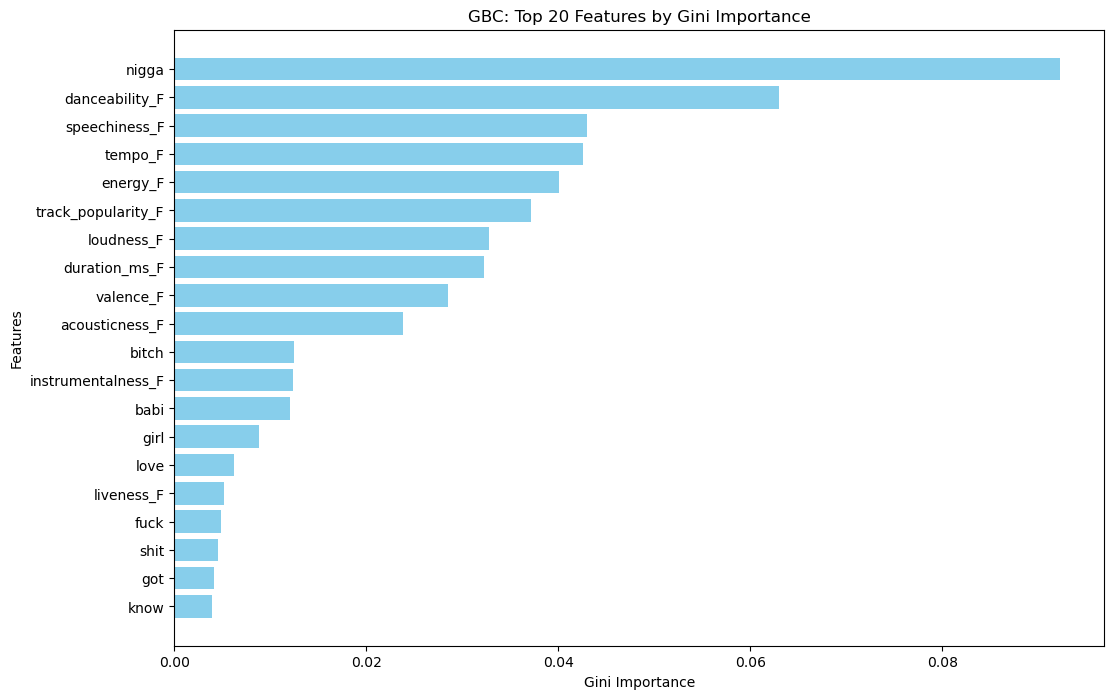

In [46]:
# Getting top GBC features
features = pd.DataFrame([GBC.feature_names_in_, GBC.feature_importances_])
features = features.transpose()
features.columns=['feature', 'gini-importance']
features = features.sort_values(by='gini-importance', ascending=False)
top_20_features = features.head(20)

# Plotting the bar chart
plt.figure(figsize=(12, 8))
plt.barh(top_20_features['feature'], top_20_features['gini-importance'], color='skyblue')
plt.xlabel('Gini Importance')
plt.ylabel('Features')
plt.title('GBC: Top 20 Features by Gini Importance')
plt.gca().invert_yaxis()  # Invert y-axis to show the most important feature at the top
plt.show()

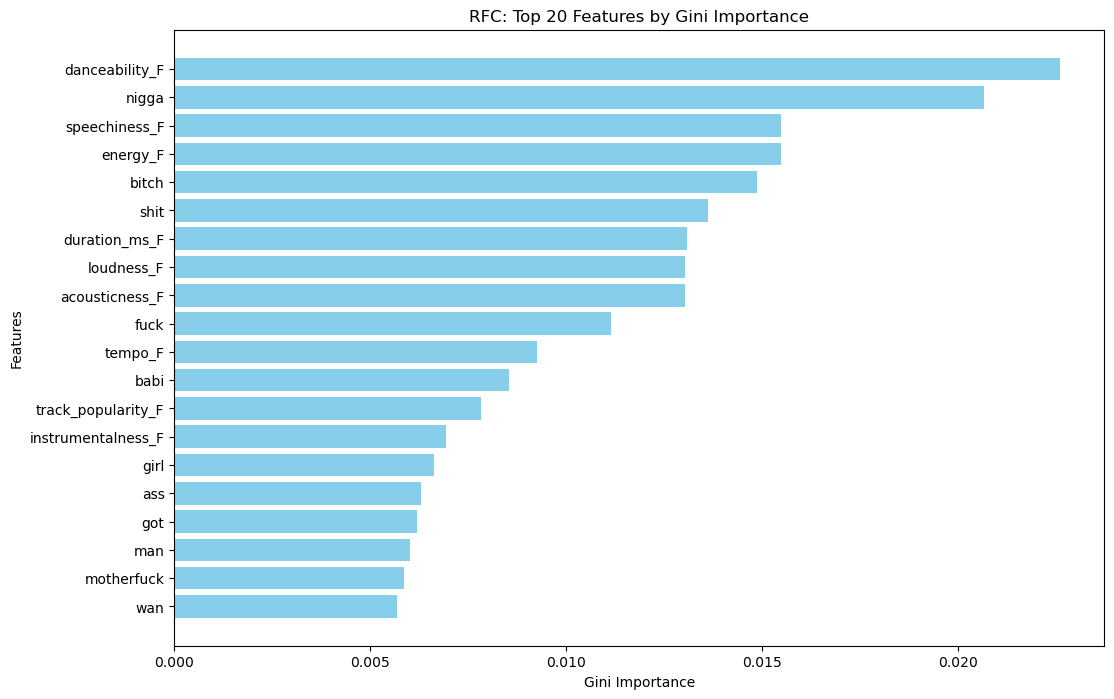

In [51]:
# Getting top RFC features
features = pd.DataFrame([RFC.feature_names_in_, RFC.feature_importances_])
features = features.transpose()
features.columns=['feature', 'gini-importance']
features = features.sort_values(by='gini-importance', ascending=False)
top_20_features = features.head(20)

# Plotting the bar chart
plt.figure(figsize=(12, 8))
plt.barh(top_20_features['feature'], top_20_features['gini-importance'], color='skyblue')
plt.xlabel('Gini Importance')
plt.ylabel('Features')
plt.title('RFC: Top 20 Features by Gini Importance')
plt.gca().invert_yaxis()  # Invert y-axis to show the most important feature at the top
plt.show()

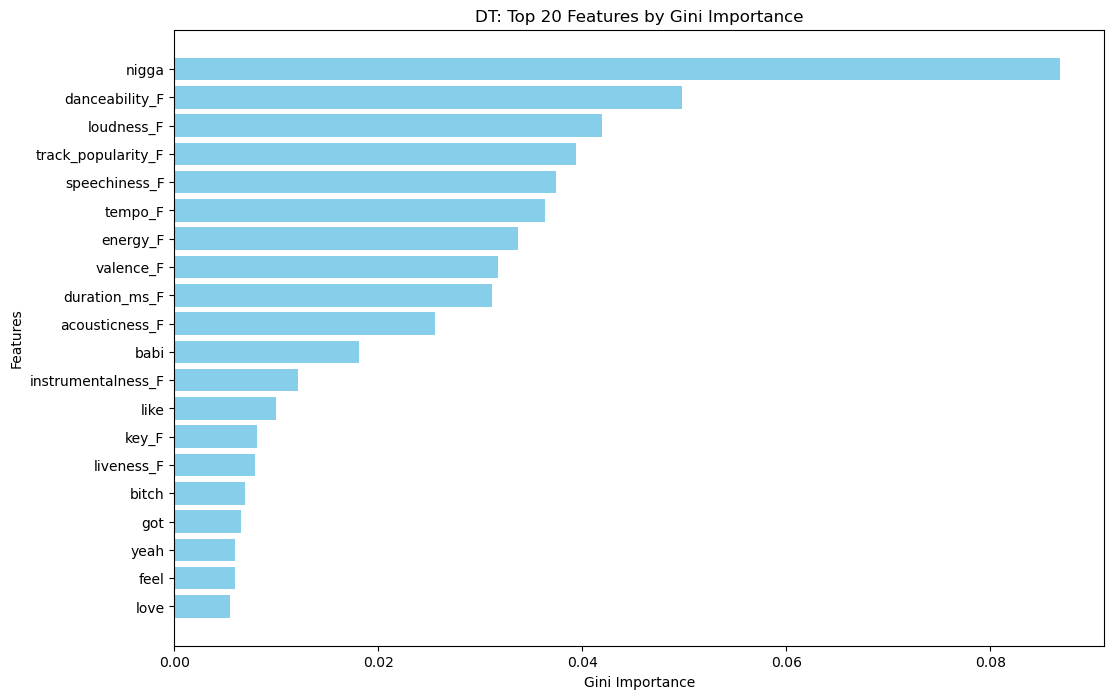

In [52]:
# Getting top DT features
features = pd.DataFrame([DT.feature_names_in_, DT.feature_importances_])
features = features.transpose()
features.columns=['feature', 'gini-importance']
features = features.sort_values(by='gini-importance', ascending=False)
top_20_features = features.head(20)

# Plotting the bar chart
plt.figure(figsize=(12, 8))
plt.barh(top_20_features['feature'], top_20_features['gini-importance'], color='skyblue')
plt.xlabel('Gini Importance')
plt.ylabel('Features')
plt.title('DT: Top 20 Features by Gini Importance')
plt.gca().invert_yaxis()  # Invert y-axis to show the most important feature at the top
plt.show()

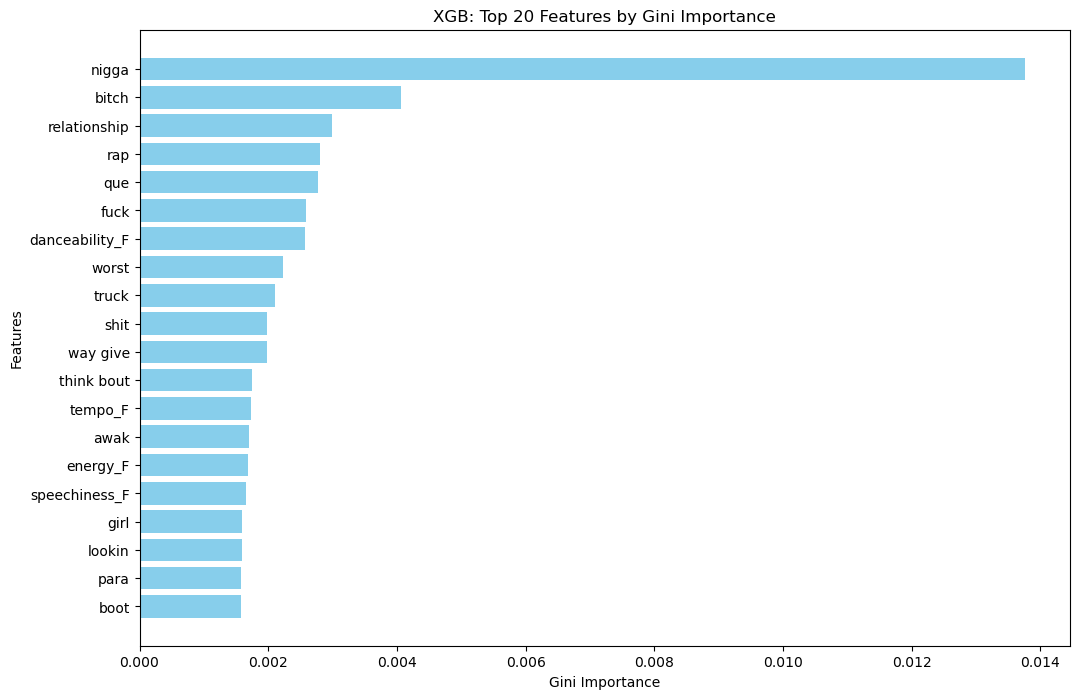

In [53]:
# Getting top XGB features
features = pd.DataFrame([XGB.feature_names_in_, XGB.feature_importances_])
features = features.transpose()
features.columns=['feature', 'gini-importance']
features = features.sort_values(by='gini-importance', ascending=False)
top_20_features = features.head(20)

# Plotting the bar chart
plt.figure(figsize=(12, 8))
plt.barh(top_20_features['feature'], top_20_features['gini-importance'], color='skyblue')
plt.xlabel('Gini Importance')
plt.ylabel('Features')
plt.title('XGB: Top 20 Features by Gini Importance')
plt.gca().invert_yaxis()  # Invert y-axis to show the most important feature at the top
plt.show()

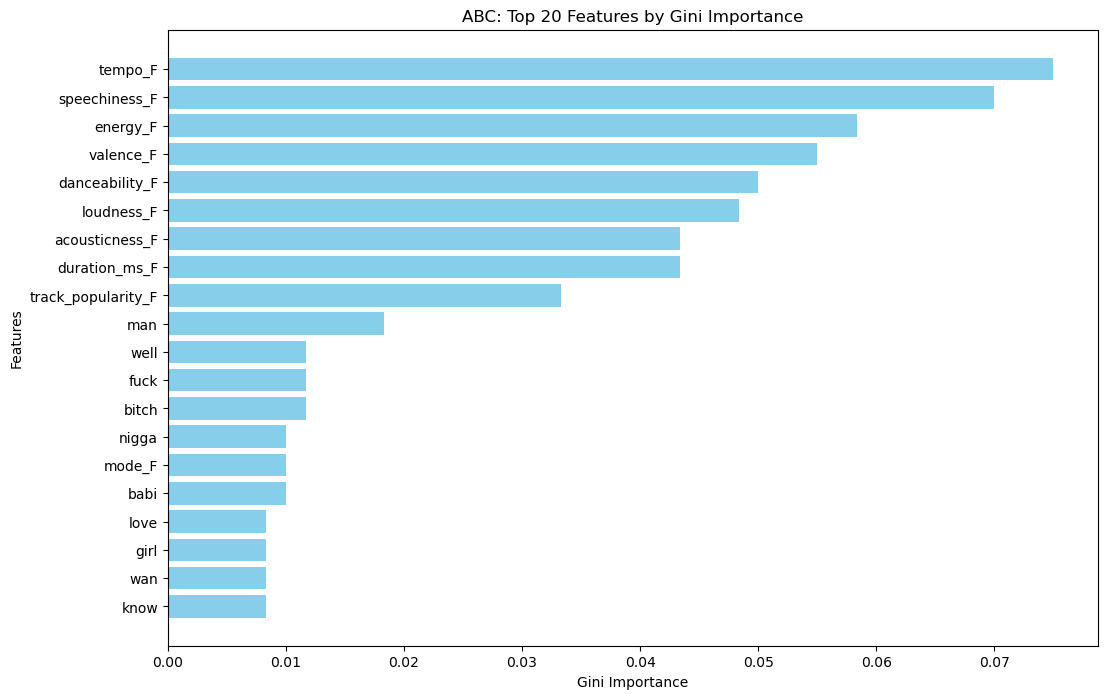

In [54]:
# Getting top ABC features
features = pd.DataFrame([ABC.feature_names_in_, ABC.feature_importances_])
features = features.transpose()
features.columns=['feature', 'gini-importance']
features = features.sort_values(by='gini-importance', ascending=False)
top_20_features = features.head(20)

# Plotting the bar chart
plt.figure(figsize=(12, 8))
plt.barh(top_20_features['feature'], top_20_features['gini-importance'], color='skyblue')
plt.xlabel('Gini Importance')
plt.ylabel('Features')
plt.title('ABC: Top 20 Features by Gini Importance')
plt.gca().invert_yaxis()  # Invert y-axis to show the most important feature at the top
plt.show()

### Stacking Classifier Training

We tried to train a model with Stacking Classifier as we did during the initial model training.
However, the training time exceeded one day again so we had to stop the training process.

In [22]:
model_abbrev = {
'GBC': ('GBC', GBC),
'DT': ('DT', DT),
'XGB': ('XGB', XGB),
'RFC': ('RFC', RFC),
'ABC': ('ABC', ABC)
}
five_highest = ['XGB', 'RFC', 'ABC', 'GBC', 'DT']
estimators = [model_abbrev[i] for i in five_highest]
SC = StackingClassifier(estimators=estimators,
                                final_estimator=LogisticRegression(solver='lbfgs', max_iter=3000), verbose=3)
print("Start Training")
model = classifier_trainer(SC, "SC", X_train, y_train, X_test, y_test)

filename ='SC_sclf.sav'
joblib.dump(model, filename)

print("Stacking Classifier Training Completed")
print("- - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - -")

Start Training


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done  16 tasks      | elapsed:   10.6s
[Parallel(n_jobs=-1)]: Done 112 tasks      | elapsed:   20.9s
[Parallel(n_jobs=-1)]: Done 200 out of 200 | elapsed:   30.1s finished


      Iter       Train Loss   Remaining Time 
         1           1.5257          326.62m
         2           1.4057          300.42m
         3           1.3082          284.44m
         4           1.2290          275.51m
         5           1.1628          275.22m
         6           1.1048          270.70m
         7           1.0568          266.74m
         8           1.0127          266.42m
         9           0.9737          263.79m
        10           0.9389          261.47m
        11           0.9092          258.45m
        12           0.8799          257.56m
        13           0.8530          255.45m
        14           0.8281          253.13m
        15           0.8069          251.11m
        16           0.7860          249.47m
        17           0.7669          247.63m
        18           0.7480          244.68m
        19           0.7307          243.03m
        20           0.7137          241.53m
        21           0.6973          240.41m
        2

[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:  4.2min remaining:    0.0s
[Parallel(n_jobs=1)]: Done   2 out of   2 | elapsed:  8.5min remaining:    0.0s
[Parallel(n_jobs=1)]: Done   5 out of   5 | elapsed: 20.3min finished
[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done  16 tasks      | elapsed:    8.1s
[Parallel(n_jobs=-1)]: Done 112 tasks      | elapsed:   15.4s
[Parallel(n_jobs=-1)]: Done 200 out of 200 | elapsed:   22.2s finished
[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  16 tasks      | elapsed:    0.0s
[Parallel(n_jobs=8)]: Done 112 tasks      | elapsed:    0.0s
[Parallel(n_jobs=8)]: Done 200 out of 200 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:   25.1s rema

      Iter       Train Loss   Remaining Time 
         1           1.5253          190.97m
         2           1.4017          200.07m
         3           1.3038          196.94m
         4           1.2229          194.27m
         5           1.1535          192.00m
         6           1.0947          190.89m
         7           1.0437          190.18m
         8           0.9964          189.82m
         9           0.9565          188.94m
        10           0.9203          187.74m
        11           0.8849          186.57m
        12           0.8559          184.94m
        13           0.8296          184.80m
        14           0.8041          184.52m
        15           0.7810          183.39m
        16           0.7587          182.38m
        17           0.7402          181.14m
        18           0.7206          180.13m
        19           0.7043          178.97m
        20           0.6878          179.17m
        21           0.6741          177.89m
        2

KeyboardInterrupt: 